# Team 
Guilherme Marin
Sharam

## Global Explanations

In this exercise, you will explore **what individual neurons in a neural network have learned to detect** using: 

1. the *activation maximization* technique we learned in the lecture.
2. the first half of *SemanticLens*.

## Setup and Imports
The exercise was tested with python 3.11.
Either create a new virtualenvironment form requirements_global.txt or add semanticlens to the venv of the shap exercise.

If you have not done so yet, download the imagenet-sample.7z from the integrated gradients exercise.
It contains 1000 images from Imagenet. Unpack it in the same Data folder which you used for the test image.

In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import random
from torch.utils.data import Dataset
from pathlib import Path
import semanticlens

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\Users\USER\Desktop\THI\05-SummerSemester\HCIandExplainableAI\XAI-HCI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
# Load pre-trained VGG16
model = models.vgg16(weights="IMAGENET1K_V1")
model.eval()
model = model.to(device)

model.name = "vgg16_imagenet"

# Let's print the model, so we see which layers we analyze later
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

# Utilization Functions

In [3]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])



def denormalize(tensor):
    """Convert normalized tensor to displayable image"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

def tensor_to_image(tensor):
    """Convert a tensor to a displayable image"""
    tensor = denormalize(tensor)
    img = tensor.squeeze(0).cpu().detach().numpy()
    img = np.transpose(img, (1, 2, 0))
    
    return img



# Exercise 1: Gradient-based Activation Maximization

Complete the following function with your own impmlementation of gradient ascent to find an input image $x^*$ that maximizes the activation $a_i(x)$ of a specific neuron $i$:
$$x^* = \arg\max_{x} a_i(x)$$ (see also in the slides of global explanations).

### Important remark!
In practice, it was shown that it helps to normalize the gradients to have a standard deviation of 1 (i.e., by dividing by the gradients std)


## Activation Maximization function

In [4]:
def activation_maximization(model, layer_idx, neuron_idx, num_steps=500, lr=0.08, device='cpu'):
    """
    Generate an image that maximizes activation of a specific neuron.
    
    Args:
        model: PyTorch model
        layer: The layer containing the neuron (e.g., model.features[2])
        neuron_idx: Index of the neuron/channel to maximize
        num_steps: Number of gradient ascent steps
        lr: Learning rate
        device: Device to run on
    
    Returns:
        The generated image (tensor)
    """
    
    # Values for imagenet normalization of the generated image
    IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
    lower = (0 - IMAGENET_MEAN) / IMAGENET_STD
    upper = (1 - IMAGENET_MEAN) / IMAGENET_STD

    # Start with a random noise tensor 
    img = torch.randn(1, 3, 224, 224, device=device, requires_grad=True)

    # 2. Gradient ascent loop
    for step in range(num_steps):
        # Zero accumulated gradients from the previous step
        if img.grad is not None:
            img.grad.zero_()
            
        # Forward only up to the selected layer
        layer_output = model.features[:layer_idx+1](img)
        if len(layer_output.shape) == 4:
            # For convolutional layers the output has shape [1, Filters, H, W].
            # We take the mean of the filter activations over the spatial map.
            activation = layer_output[0, neuron_idx].mean()
        else:
            # For fully connected layers, we simply look at the activation of the neuron
            activation = layer_output[0, neuron_idx]

        # Backpropagate: compute d(activation)/d(img)
        activation.backward()

        # Normalize gradient to std=1 (stabilizes training, avoids vanishing/exploding updates)
        grad = img.grad.data
        grad_std = grad.std()
        if grad_std > 1e-8:
            grad = grad / grad_std

        # Gradient ASCENT: move the image in the direction that INCREASES activation
        with torch.no_grad():
            img.data += lr * grad
            # Clamp to valid ImageNet-normalized range [lower, upper]
            img.data = torch.max(torch.min(img.data, upper), lower)

    return img.detach()

def show_neuron_activation(img, layer_name, layer_idx, neuron_idx):
    img_display = tensor_to_image(img)

    plt.imshow(img_display)
    plt.suptitle(f'{layer_name} (Layer {layer_idx})', fontsize=14)
    plt.title(f'Neuron {neuron_idx}')
    plt.tight_layout()
    plt.show()

## **Visualize Layers**

To test your function apply it to neurons in three different convolutional layers. 
An early layer, a middle layer and a late layer. 
What do you observe?

In [5]:
layer_name = "conv1_2 (Early Layer)"
layer_idx = 2  # conv1_2
neuron_idx = 5
img = activation_maximization(model, layer_idx, neuron_idx, num_steps=500, device=device)

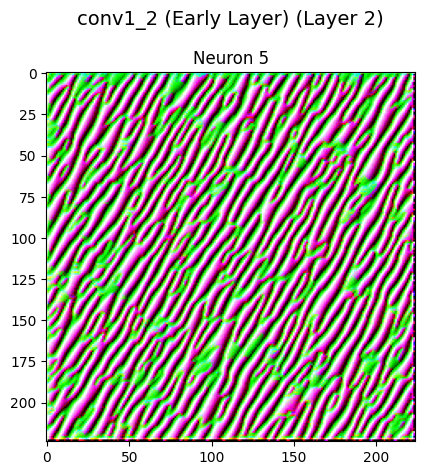

In [6]:
show_neuron_activation(img, layer_name, layer_idx, neuron_idx)

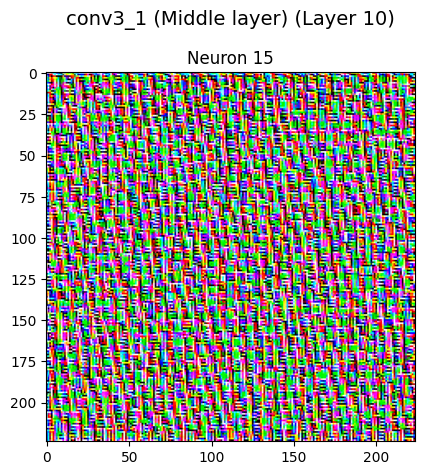

In [7]:
layer_name = "conv3_1 (Middle layer)"
layer_idx = 10  # conv3_1
neuron_idx = 15
img = activation_maximization(model, layer_idx, neuron_idx, num_steps=500, device=device)
show_neuron_activation(img, layer_name, layer_idx, neuron_idx)

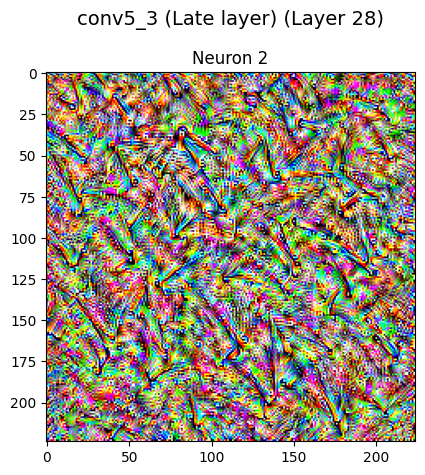

In [8]:
layer_name = "conv5_3 (Late layer)"
layer_idx = 28  # conv5_1
neuron_idx = 2
img = activation_maximization(model, layer_idx, neuron_idx, num_steps=500, device=device)
show_neuron_activation(img, layer_name, layer_idx, neuron_idx)

# Exercise 2: SemanticLens Activation Maximization Sampling

SemanticLens is a **framework that maps neurons to a semantic space by finding the input images that activate them**. It uses **activation maximization sampling**: for each neuron, it finds the top `k` most activating images from a dataset.

In this exercise, you will use their provided package, to find **images that maximally activate neurons**.

### 2.1 **Build Datasets for SemanticLens**

SemanticLens expects two torch Datasets:
- `dataset_model`: Returns tensors for the VGG model (normalized)
- `dataset_fm`: Returns raw PIL images for the foundation model. We will not need this for the exercise, but semanticlens requires it.

The following code creates these two Datasets from our imagenet sample data:

In [9]:
# ImageNet validation samples
folder = Path("../Data/imagenet-sample/data")

image_paths = [str(p) for p in folder.iterdir() if p.is_file()]

# Shuffle for diversity
random.seed(42)
random.shuffle(image_paths)

# Dataset classes
class ImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.transform = transform
        self.images_pil = [Image.open(p).convert('RGB') for p in paths]
        self.name = "imagenet_subset_model"
    def __len__(self): return len(self.images_pil)
    def __getitem__(self, idx): return self.transform(self.images_pil[idx]), -1

class ImageDatasetFM(Dataset):
    def __init__(self, paths):
        self.images_pil = [Image.open(p).convert('RGB') for p in paths]
        self.name = "imagenet_subset_fm"
    def __len__(self): return len(self.images_pil)
    def __getitem__(self, idx): return self.images_pil[idx]

dataset_model = ImageDataset(image_paths, transform=preprocess)
dataset_foundation_model = ImageDatasetFM(image_paths)

print(f"dataset_model length: {len(dataset_model)}")
print(f"dataset_foundation_model length:   {len(dataset_foundation_model)}")

FileNotFoundError: [WinError 3] O sistema não pode encontrar o caminho especificado: '..\\Data\\imagenet-sample\\data'

### 2.2 **Initialize SemanticLens Components**


In [ ]:
layer_names = ["features.28"] # Last convolutional layer, as shown in the model description above

component_visualizer = semanticlens.component_visualization.ActivationComponentVisualizer(
    model=model,
    dataset_model=dataset_model,
    dataset_fm=dataset_foundation_model,
    layer_names=layer_names,
    num_samples=30,
    device=device,
    cache_dir="./cache",
)

### 2.3 **Run ActMax Sampling**
Now that we set up the component viusalizer, it is your job to run it. 
Use the run function, to create an actmax_cache.
For more information on this function, check the official repository: https://github.com/jim-berend/semanticlens/blob/main/semanticlens/component_visualization/activation_based.py 

In [ ]:
# Run the component viusalizer for the whole dataset.
# TODO 

Running activation maximization sampling...


sample_ids shape: torch.Size([512, 30])
Number of neurons: 512
Number of ActMax samples per neuron: 30


### 2.4 **Visualize ActMax Samples**
Now let's visualize the top-activating images for different neurons.
For this, we will use the visualize_components function of the component visualizer (see the official repository for more information: https://github.com/jim-berend/semanticlens/blob/main/semanticlens/component_visualization/activation_based.py) 
Also see : https://github.com/jim-berend/semanticlens/blob/main/tutorials/quickstart.ipynb

Top 5 neurons by max activation: [64, 156, 458, 224, 428]
Their max activations: [11.5, 10.6875, 10.4375, 10.0625]
Visualizing the Top neurons by max activation.


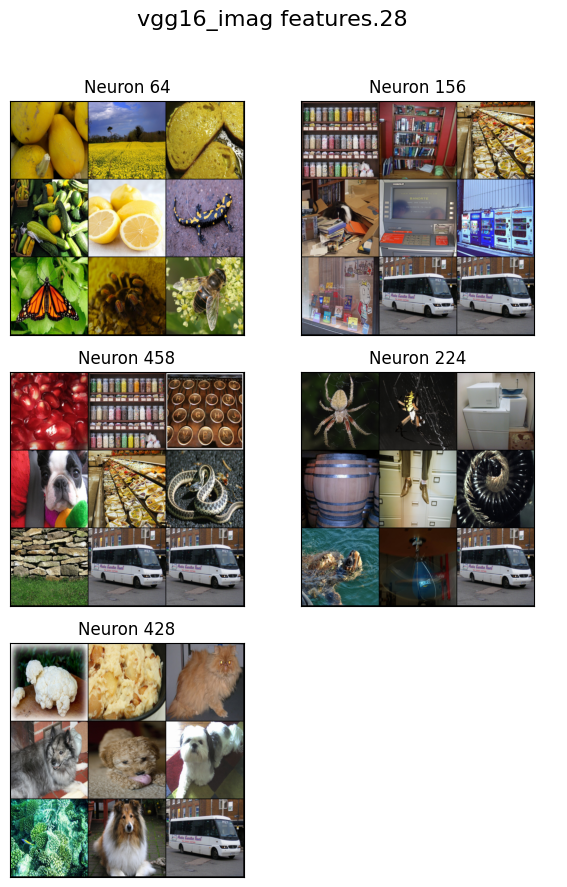

Saved visualization to cache\ActivationComponentVisualizer\imagenet_subset_model\vgg16_imagenet\plots\features.28_64-156-458-224-428.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Get the 5 neurons that have the highest average activations.
# TODO

# Get their indices
# TODO

print(f"Visualizing the Top neurons by max activation.")
# TODO
